<div style="background:#0A2540;color:white;padding:18px 22px;border-radius:8px"><div style="color:#F4B942;font-weight:700;letter-spacing:1px">WEEK 6 · TUTORIAL 3 (LIVE SCRIPT)</div><div style="font-size:24px;font-weight:800;margin:4px 0">Model Evaluation — Metrics for Triage</div><div style="opacity:.9">Choose and justify the right metric for an imbalanced, safety-critical problem.</div><div style="margin-top:8px;font-size:13px;opacity:.75">Audience: Caribbean Clinical-AI trainees · Mercer General Hospital · dataset: Yale EMMLC (cleaned)</div></div>

### What you'll do today
1. Rebuild your two models from Tutorial 2 (so this notebook runs on its own).
2. Read a **confusion matrix** in a triage context.
3. Compute **accuracy, precision, recall, F1** — and understand what each means clinically.
4. Learn why **recall for ESI 1** is the number that matters most.
5. Build a small comparison table and save your confusion-matrix figure.

<div style="border-left:6px solid #1B9AAA;background:#1B9AAA14;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#1B9AAA">🩺 CLINICAL CONTEXT</b><br>A false negative for an <b>ESI 1</b> patient means the model called a dying patient ‘not urgent’. That is not the same kind of mistake as over-calling a stable patient. Today is about measuring the mistakes that actually hurt people — not just counting how often we're right.</div>

In [1]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: loads the Python "tools" (libraries) we need.
#   - pandas: works with tables of data (like a spreadsheet in code)
#   - matplotlib: draws charts
#   - scikit-learn (sklearn): the machine-learning toolkit
#   - joblib: saves a trained model to a file so we can reuse it later
# You only run this once at the top of the notebook.
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

pd.set_option("display.width", 120)
print("Libraries loaded. ✅")

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, recall_score,
)

Libraries loaded. ✅


In [8]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/CariSurg/triage_cleaned_v1.csv")
print("Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 55121 patients and 225 columns.


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,A,4,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,B,2,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A,2,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,A,3,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,A,2,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
!ls '/content/drive/MyDrive/'

'2025 FGC Consent and Release Agreement.gdoc'
'2025 FGC Consent and Release Agreement.pdf'
'API Key.gdoc'
'Assignment 6_ Triage Pseudocode (1).pdf'
'Assignment 6: Triage Pseudocode.gdoc'
 Attendance.gsheet
 Bio.gdoc
'BoQ - Landscaping - Rodney Bay Complex St Lucia.xlsx'
 CariSurg
' CariSurg Week 1 Final Deliverable.gdoc'
'CariSurg Week 1 Interim.gdoc'
'CariSurg Week 1 Interim.pdf'
'CariSurg Week 2 Final Submission.gdoc'
'CariSurg Week 2 Final Submission.pdf'
'CariSurg Week 2 Interim Submission  (1).gdoc'
'CariSurg Week 2 Interim Submission .gdoc'
 Classroom
'Colab Notebooks'
'Copy of Aiden Daniel Resume.gdoc'
'Copy of Aiden Daniel Resume.pdf'
'Copy of Preliminary Proposal- Carisurg Week 2 Final Deliverable.gdoc'
'Copy of Week3_Interim_Submission.gdoc'
'Cover Letter.gdoc'
"Cover Letter-Reservation's Agent.gdoc"
 createLikelyQuiz.gscript
' CV Pershawn Jn Pierre (1).gdoc'
' CV Pershawn Jn Pierre.gdoc'
 EmergencyTriageDataset_Reduced_Dirty.csv
'ETH 101 Research Paper.gdoc'
'Feasibility Mem

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>We rebuild the same X/y, the same split, and the same two models as Tutorial 2. Because we reuse the same <code>random_state</code>, we get the <i>identical</i> split — that's what makes results reproducible. If you saved your models with joblib, you could <code>joblib.load</code> them instead.</div>

In [9]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

In [10]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: recreates Tutorial 2's features, split, and models,
# so Tutorial 3 stands on its own. Same random_state = same split.
# ------------------------------------------------------------------
X, y = df[FEATURES], df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Logistic regression needs scaling; the tree does not.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_s, y_train)
tree   = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)
dummy  = DummyClassifier(strategy="stratified", random_state=42).fit(X_train, y_train)
print("Models ready. ✅")

Models ready. ✅


## 1 · Make predictions on the test set

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br><code>.predict(...)</code> asks a trained model for its ESI guess on each test patient. Remember logistic regression must see the <b>scaled</b> test features (<code>X_test_s</code>), while the tree uses the original <code>X_test</code>.</div>

In [11]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: gets each model's predicted ESI for the test set.
# ------------------------------------------------------------------
pred_logreg = logreg.predict(X_test_s)   # scaled features for LR
pred_tree   = tree.predict(X_test)       # unscaled for the tree
print("Example predictions (logreg):", pred_logreg[:10])

Example predictions (logreg): [2 3 3 2 2 2 3 3 3 2]


## 2 · The confusion matrix

📚 **scikit-learn docs:** [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)  ·  [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)

Before you plot your own, here is how to read one. Our real matrix has all five ESI levels, but the idea is clearest with a single class — 'urgent' vs 'not':

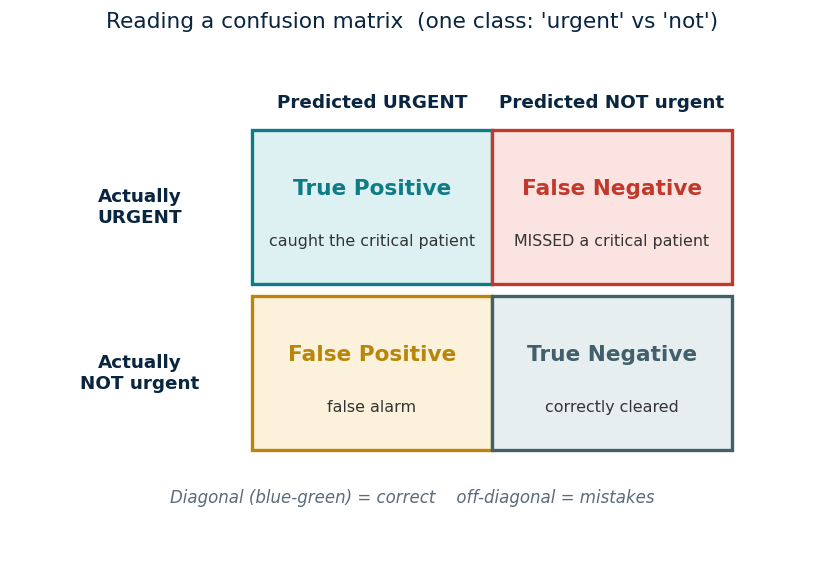

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>A <b>confusion matrix</b> is a grid: rows are the <i>true</i> ESI level, columns are what the model <i>predicted</i>. The diagonal is where it got it right. Everything off the diagonal is a mistake — and the matrix shows you <i>which</i> levels get confused for which. That detail is invisible in a single accuracy number.</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Draw the confusion matrix for the logistic-regression predictions using <code>ConfusionMatrixDisplay.from_predictions(...)</code>.</div>

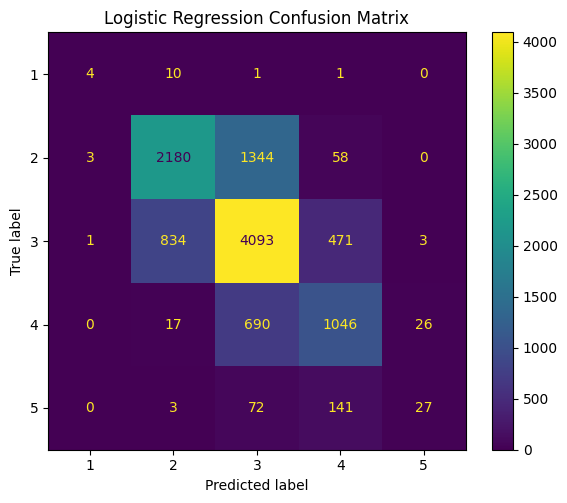

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

# ------------------------------------------------------------------
# WHAT THIS CELL DOES: draws the confusion matrix for logistic regression.
# Rows = true ESI, columns = predicted ESI. Diagonal = correct.
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_logreg,
    ax=ax
)

ax.set_title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()

## 3 · Accuracy, precision, recall, F1

📚 **scikit-learn docs:** [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)  ·  [`Precision, recall & F-measures (user guide)`](https://scikit-learn.org/stable/modules/model_evaluation.html#precision-recall-f-measure-metrics)

This picture is the one to remember. **Precision** and **recall** both count the same true positives (TP) — they just divide by different things. Precision asks *‘of what I flagged, how much was right?’* (a column); recall asks *‘of what was truly urgent, how much did I catch?’* (a row).

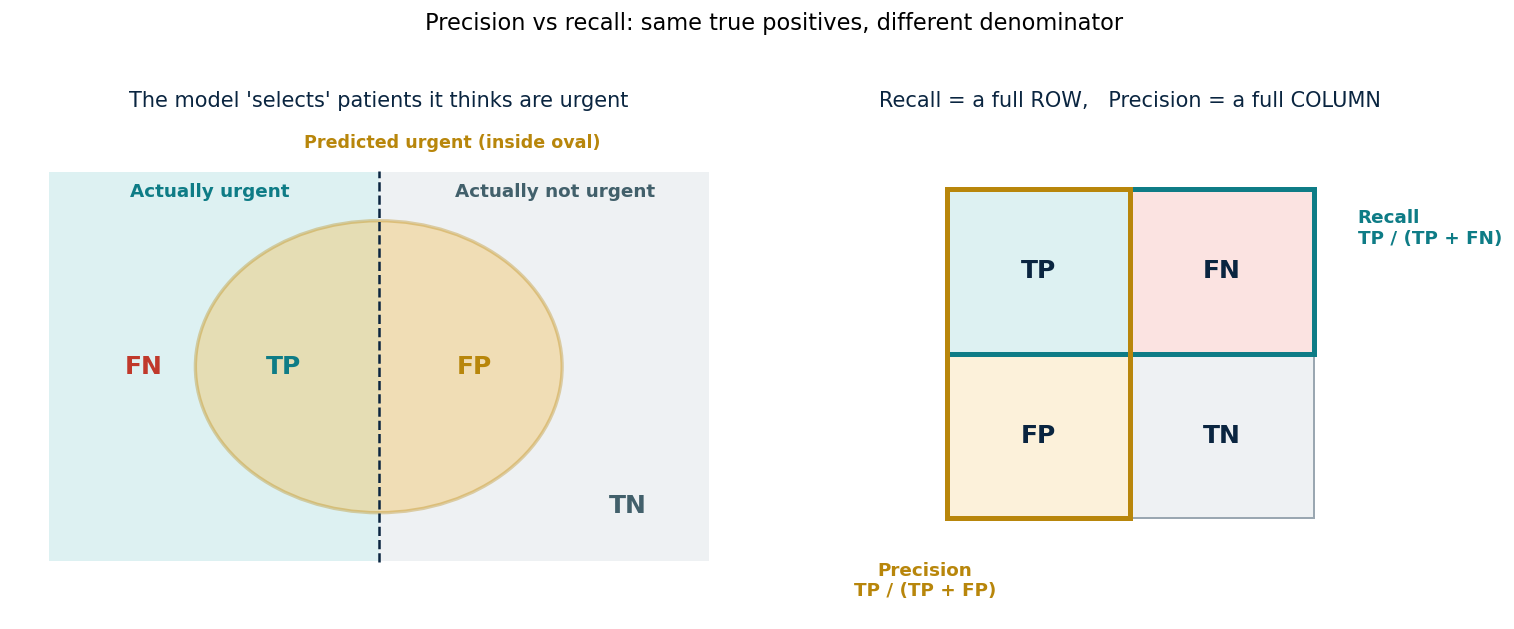

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>Four words, plain English, for one class at a time:<br>• <b>Accuracy</b> — of all patients, what fraction did we label correctly? (whole-dataset)<br>• <b>Precision</b> — when the model <i>says</i> ESI 1, how often is it right? (few false alarms)<br>• <b>Recall</b> — of the patients who <i>really are</i> ESI 1, how many did we catch? (few misses)<br>• <b>F1</b> — a single score that balances precision and recall.</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Print the full <code>classification_report(...)</code> for the logistic-regression predictions — it lists precision, recall and F1 for every ESI level at once.</div>

In [16]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: prints precision / recall / F1 for EACH ESI level.
# ------------------------------------------------------------------
# TODO —
#   - call classification_report(...) with the true labels and pred_logreg
#   - wrap it in print(...); add digits=3 for readable numbers

print(classification_report(
    y_test,
    pred_logreg,
    digits=3
))


              precision    recall  f1-score   support

           1      0.500     0.250     0.333        16
           2      0.716     0.608     0.658      3585
           3      0.660     0.758     0.706      5402
           4      0.609     0.588     0.598      1779
           5      0.482     0.111     0.181       243

    accuracy                          0.667     11025
   macro avg      0.594     0.463     0.495     11025
weighted avg      0.666     0.667     0.661     11025



## 4 · Macro vs weighted F1

📚 **scikit-learn docs:** [`f1_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)

The two averages weight the classes differently — and that choice decides whether the rare, critical ESI 1 gets a real say:

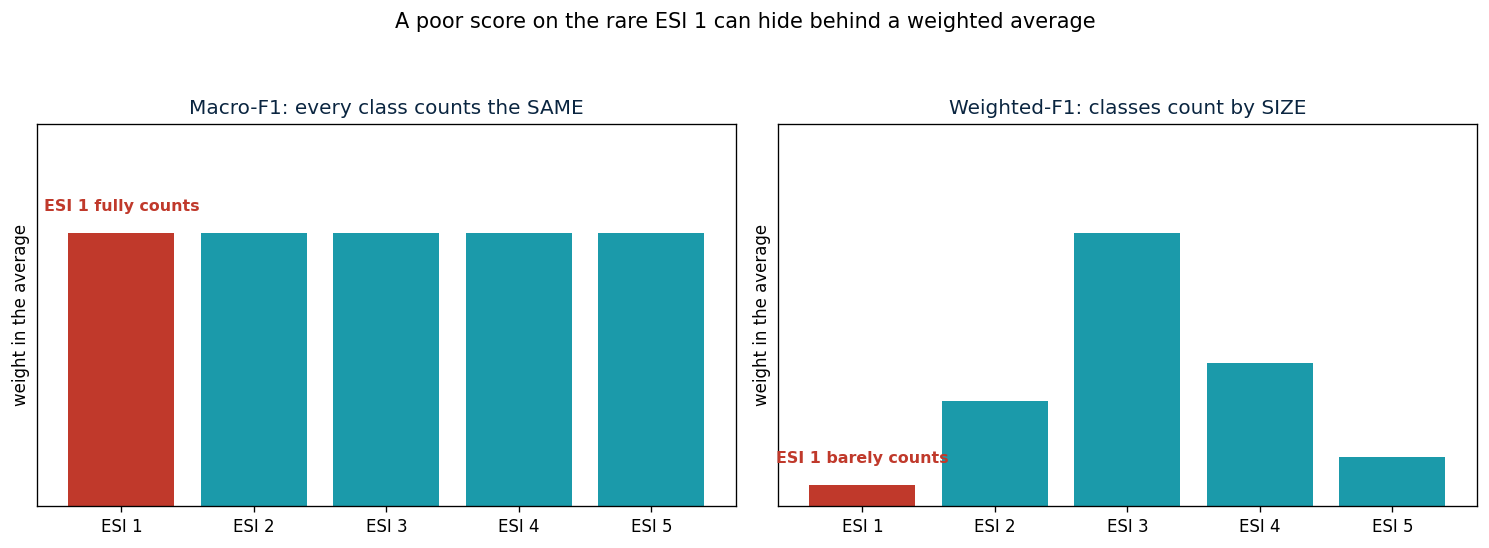

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>There are two ways to average F1 across the 5 ESI levels. <b>Weighted</b> F1 gives big classes more say — so a great score on the common ESI 3 can hide a terrible score on the rare ESI 1. <b>Macro</b> F1 treats every class equally, so the rare-but-critical classes can't be swept under the rug. For triage we lean on <b>macro</b>.</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Compute both averages with <code>f1_score(...)</code> using <code>average="macro"</code> and <code>average="weighted"</code>, and print them side by side.</div>

In [17]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: compares the two ways of averaging F1.
# macro = every ESI level counts equally; weighted = big classes dominate.
# ------------------------------------------------------------------
# TODO —
#   - use f1_score(y_test, pred_logreg, average="macro")   for macro F1
#   - use f1_score(..., average="weighted")                for weighted F1
#   - print both, rounded

macro_f1 = f1_score(y_test, pred_logreg, average="macro")
weighted_f1 = f1_score(y_test, pred_logreg, average="weighted")

print("Macro F1:   ", round(macro_f1, 3))
print("Weighted F1:", round(weighted_f1, 3))

Macro F1:    0.495
Weighted F1: 0.661


## 5 · The number that matters most: recall for ESI 1

📚 **scikit-learn docs:** [`recall_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)

Why we obsess over this one number: recall for ESI 1 is literally the fraction of the sickest patients the model catches. Picture 20 truly-critical patients —

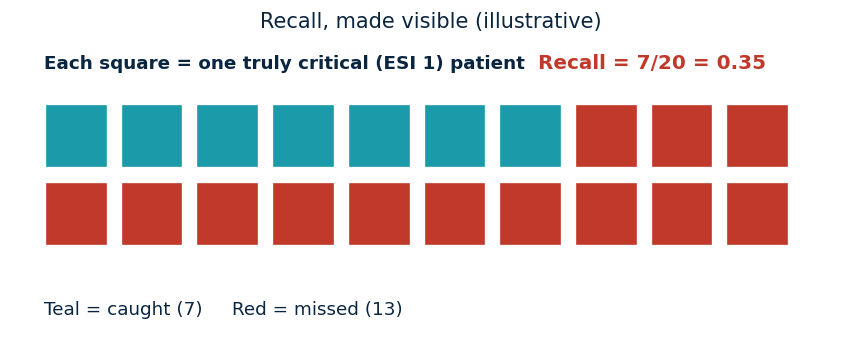

<div style="border-left:6px solid #1B9AAA;background:#1B9AAA14;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#1B9AAA">🩺 CLINICAL CONTEXT</b><br>If you remember one metric from this whole week, make it this: <b>recall for ESI 1</b> — the share of truly critical patients the model actually flags as critical. A missed ESI 1 is the failure mode with the worst clinical consequence.</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Use <code>recall_score(...)</code> with <code>labels=[1]</code> and <code>average=None</code> to pull out the recall for ESI level 1 specifically (compare logistic regression vs the tree).</div>

In [18]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: extracts recall for ESI level 1 for each model.
# recall_score(..., labels=[1], average=None) returns a list with just
# the ESI-1 recall, so we take element [0].
# ------------------------------------------------------------------
# TODO —
#   - call recall_score(y_test, pred_logreg, labels=[1], average=None)
#   - take element [0] to get the ESI-1 recall number
#   - do the same for the tree (tree.predict(X_test)) and print both

logreg_recall_esi1 = recall_score(
    y_test,
    pred_logreg,
    labels=[1],
    average=None
)[0]

tree_recall_esi1 = recall_score(
    y_test,
    tree.predict(X_test),
    labels=[1],
    average=None
)[0]

print("Logistic Regression ESI-1 Recall:", round(logreg_recall_esi1, 3))
print("Decision Tree ESI-1 Recall:      ", round(tree_recall_esi1, 3))


Logistic Regression ESI-1 Recall: 0.25
Decision Tree ESI-1 Recall:       0.0


## 6 · Compare the models at a glance

In [19]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: collects the key numbers into one small table so
# you can compare the dummy baseline, logistic regression, and the tree.
# ------------------------------------------------------------------
def summarise(name, preds):
    return {
        "model": name,
        "accuracy": round((preds == y_test).mean(), 3),
        "macro_F1": round(f1_score(y_test, preds, average="macro"), 3),
        "recall_ESI1": round(recall_score(y_test, preds, labels=[1], average=None)[0], 3),
    }

table = pd.DataFrame([
    summarise("Dummy (baseline)", dummy.predict(X_test)),
    summarise("Logistic Regression", pred_logreg),
    summarise("Decision Tree", tree.predict(X_test)),
])
table

,model,accuracy,macro_F1,recall_ESI1
0,Dummy (baseline),0.375,0.204,0.00
1,Logistic Regression,0.667,0.495,0.25
2,Decision Tree,0.556,0.216,0.00


<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>This little helper runs the same three measurements on each model and stacks them into a table with <code>pd.DataFrame([...])</code>. A comparison table like this is the heart of your Week 6 baseline report — it shows, honestly, that the real models beat the dummy and where they still fall short.</div>

## 7 · Save your confusion-matrix figure

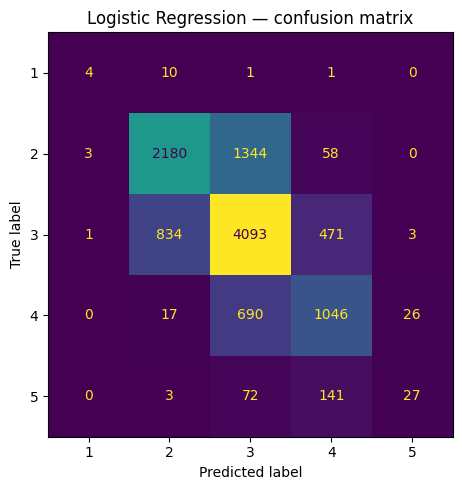

Saved figs/w6_confusion_logreg.png ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: saves the confusion matrix to figs/ so you can
# commit it to GitHub and drop it into your report.
# ------------------------------------------------------------------
import os
os.makedirs("figs", exist_ok=True)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, colorbar=False)
ax.set_title("Logistic Regression — confusion matrix")
plt.tight_layout()
plt.savefig("figs/w6_confusion_logreg.png", dpi=110)
plt.show()
print("Saved figs/w6_confusion_logreg.png ✅")
from google.colab import files

files.download("figs/w6_confusion_logreg.png")

## 8 · Exercises
1. Draw the confusion matrix for the **decision tree** too. Which levels does it confuse most?
2. Which model would you trust more for triage, and **why** — quote a specific number.
3. In one sentence, explain to a nurse why **accuracy alone** is not enough here.

Commit your notebook and the saved figure to your repo.

## 📚 Further reading — scikit-learn documentation

Every scikit-learn tool used in this notebook, linked to its official reference. When a function has more options than we used here, this is where to look them up.
- [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
- [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
- [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
- [`f1_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)
- [`recall_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)
- [`Precision, recall & F-measures (user guide)`](https://scikit-learn.org/stable/modules/model_evaluation.html#precision-recall-f-measure-metrics)